# Post-processing RL candidates: trace DORAnet reaction networks

This notebook traces top RL/Pareto candidates back to the exact DORAnet reaction-network JSON files generated during the RL loop.

It is designed for outputs from `runRL_traceable.py`, especially:

- `rl_multiobjective_generated_candidates.csv`
- `rl_multiobjective_pareto_front_ranked.csv`
- `doranet_job_map.csv`
- `doranet_action_map.csv`

The notebook also creates visual summaries:
- potency–toxicity plot with top candidates highlighted
- route-step tables
- molecule grids for top candidates
- source-to-product route maps
- optional network-size summaries from DORAnet JSON files


## 1. Configuration

Edit `outputDir` to point to the RL output directory.

In [1]:
from pathlib import Path

# Change this path if needed
outputDir = Path("RL_outputs_multiobjective")

# Candidate files
generatedCsv = outputDir / "rl_multiobjective_generated_candidates.csv"
paretoRankedCsv = outputDir / "rl_multiobjective_pareto_front_ranked.csv"
paretoFrontCsv = outputDir / "rl_multiobjective_pareto_front.csv"

# DORAnet traceability files produced by runRL_traceable.py
jobMapCsv = outputDir / "doranet_job_map.csv"
actionMapCsv = outputDir / "doranet_action_map.csv"

# Output directory for this post-processing notebook
traceOutputDir = outputDir / "reaction_trace_postprocessing"
traceOutputDir.mkdir(parents=True, exist_ok=True)

topK = 20
print("Output directory:", outputDir.resolve())
print("Trace output directory:", traceOutputDir.resolve())


Output directory: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB/Reinforcement_Learning/run1_serial/RL_outputs_multiobjective
Trace output directory: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB/Reinforcement_Learning/run1_serial/RL_outputs_multiobjective/reaction_trace_postprocessing


## 2. Imports and helper functions

In [2]:
import ast
import json
import math
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import Draw, QED
from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")


def loadCsv(path, required=False):
    path = Path(path)
    if not path.exists():
        if required:
            raise FileNotFoundError(f"Missing required file: {path}")
        print(f"Warning: file not found: {path}")
        return pd.DataFrame()
    DF = pd.read_csv(path)
    DF.columns = [str(c).replace("\ufeff", "").strip() for c in DF.columns]
    return DF


def canonicalizeSmiles(smiles):
    if pd.isna(smiles):
        return None
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None
    return Chem.MolToSmiles(mol, canonical=True)


def safeList(value):
    """Convert stored route metadata to a Python list.

    Handles actual lists, JSON-like strings, Python-list strings, semicolon strings,
    and missing values.
    """
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return []
    if isinstance(value, list):
        return value
    text = str(value).strip()
    if text == "" or text.lower() in {"nan", "none"}:
        return []
    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, list):
            return parsed
        return [parsed]
    except Exception:
        pass
    if ";" in text:
        return [x.strip() for x in text.split(";") if x.strip()]
    if "|" in text:
        return [x.strip() for x in text.split("|") if x.strip()]
    return [text]


def loadJson(path):
    path = Path(path)
    if not path.exists():
        return None
    try:
        with open(path, "r") as f:
            return json.load(f)
    except Exception as exc:
        print(f"Could not load JSON {path}: {exc}")
        return None


def getMol(smiles):
    if pd.isna(smiles):
        return None
    return Chem.MolFromSmiles(str(smiles))


def displayMoleculeGrid(smilesList, legends=None, molsPerRow=4, subImgSize=(280, 220)):
    mols = [getMol(s) for s in smilesList]
    legends = legends or [str(i) for i in range(len(mols))]
    return Draw.MolsToGridImage(
        mols,
        legends=legends,
        molsPerRow=molsPerRow,
        subImgSize=subImgSize,
        useSVG=False,
    )


## 3. Load RL, Pareto, and DORAnet mapping outputs

In [3]:
generatedDF = loadCsv(generatedCsv, required=True)
paretoRankedDF = loadCsv(paretoRankedCsv, required=False)
paretoFrontDF = loadCsv(paretoFrontCsv, required=False)
jobMapDF = loadCsv(jobMapCsv, required=False)
actionMapDF = loadCsv(actionMapCsv, required=False)

print("Generated candidates:", generatedDF.shape)
print("Ranked Pareto front:", paretoRankedDF.shape)
print("Pareto front:", paretoFrontDF.shape)
print("DORAnet job map:", jobMapDF.shape)
print("DORAnet action map:", actionMapDF.shape)

display(generatedDF.head())


Generated candidates: (20, 169)
Ranked Pareto front: (13, 177)
Pareto front: (13, 171)
DORAnet job map: (104, 8)
DORAnet action map: (2496, 7)


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,logP,...,mo_qed,mo_route,mo_uncertainty,potencyRewardComponent,toxicityRewardComponent,qedRewardComponent,routeRewardComponent,uncertaintyRewardComponent,totalRewardBeforePareto,paretoBonus
0,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,5.629883,0.545017,4.561651,6.698116,0.000002,2.003938e-07,0.000027,809.578,-1.31540,...,0.000399,0.9,-2.0,0.656879,0.002364,0.000399,0.9,-2.0,0.219914,0.08
1,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,5.447737,0.540431,4.388491,6.506983,0.000004,3.111842e-07,0.000041,785.557,-2.42396,...,0.000299,0.7,-2.0,0.435040,0.000449,0.000299,0.7,-2.0,0.093414,-0.08
2,O=C[C@]1(n2cnc3c(=O)[nH]cnc32)OC[C@@H](O)[C@H]1O,5.254010,0.544925,4.185956,6.322063,0.000006,4.763613e-07,0.000065,266.213,-2.27670,...,0.808249,1.0,-2.0,0.226190,0.024502,0.808249,1.0,-2.0,0.071355,-0.08
3,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,5.315121,0.543254,4.250343,6.379898,0.000005,4.169669e-07,0.000056,427.203,-1.74600,...,0.032793,0.7,-2.0,0.284063,0.008779,0.032793,0.7,-2.0,0.015709,-0.08
4,C#[O+],5.330150,0.544133,4.263649,6.396650,0.000005,4.011897e-07,0.000054,29.018,0.00590,...,0.088871,0.9,-2.0,0.299590,0.377580,0.088871,0.9,-2.0,0.095978,0.08


## 4. Select top candidates for tracing

Priority:
1. ranked Pareto front, if available
2. Pareto front, if available
3. generated candidates ranked by `reward`


In [4]:
def selectTopCandidates(generatedDF, paretoRankedDF, paretoFrontDF, topK=20):
    if paretoRankedDF is not None and not paretoRankedDF.empty:
        topDF = paretoRankedDF.copy()
        sourceName = "ranked Pareto front"
    elif paretoFrontDF is not None and not paretoFrontDF.empty:
        topDF = paretoFrontDF.copy()
        sourceName = "Pareto front"
    else:
        topDF = generatedDF.copy()
        sourceName = "generated candidates"
        if "reward" in topDF.columns:
            topDF = topDF.sort_values("reward", ascending=False)

    if "SMILES" not in topDF.columns:
        raise ValueError("Selected candidate dataframe does not contain a SMILES column.")

    topDF["canonicalSmiles"] = topDF["SMILES"].apply(canonicalizeSmiles)
    topDF = topDF.dropna(subset=["canonicalSmiles"]).drop_duplicates("canonicalSmiles").head(topK).reset_index(drop=True)
    print(f"Using top {len(topDF)} candidates from: {sourceName}")
    return topDF

topCandidateDF = selectTopCandidates(generatedDF, paretoRankedDF, paretoFrontDF, topK=topK)

cols = [c for c in [
    "SMILES", "pPotency_prediction", "coreToxicityScore", "QED", "pPotency_std",
    "reward", "paretoRank", "paretoRankScore", "preferencePolicy"
] if c in topCandidateDF.columns]

display(topCandidateDF[cols])
topCandidateDF.to_csv(traceOutputDir / "top_candidates_selected.csv", index=False)


Using top 13 candidates from: ranked Pareto front


,SMILES,pPotency_prediction,coreToxicityScore,QED,pPotency_std,reward,paretoRank,paretoRankScore,preferencePolicy
0,O=C(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H]...,5.439854,0.337565,0.485234,0.540909,0.143443,1,0.684615,safety_focused
1,O=P(O)(O)OP(=O)(O)O,5.389426,0.306393,0.407078,0.542553,0.151562,2,0.680769,balanced
2,C#[O+],5.330150,0.239987,0.333625,0.544133,0.175978,3,0.634615,balanced
3,C[n+]1cn([C@@H]2O[C@H](C(=O)O)[C@@H](O)[C@H]2O...,5.296519,0.251765,0.440238,0.541002,0.191499,4,0.573077,safety_focused
4,F,5.311845,0.246626,0.350795,0.544203,0.165281,5,0.565385,balanced
5,CC(C)=CCOP(=O)(O)OP(=O)(O)O,5.382517,0.526286,0.492503,0.543583,-0.111489,6,0.530769,safety_focused
6,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,5.447737,0.816600,0.044261,0.540431,0.013414,7,0.511538,potency_focused
7,O=C(O)[C@]1(n2cnc3c(=O)[nH]cnc32)OC[C@@H](O)[C...,5.284240,0.322860,0.475998,0.543808,0.111039,8,0.450000,safety_focused
8,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,5.346715,0.588693,0.062571,0.540573,-0.182417,9,0.446154,safety_focused
9,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,5.629883,0.683606,0.058692,0.545017,0.299914,10,0.438462,potency_focused


## 5. Match top candidates to rollout rows with route metadata

The ranked Pareto CSV may not contain route metadata, so this cell joins top candidates back to the generated-candidates CSV.

In [5]:
def matchTopCandidatesToRollouts(topCandidateDF, generatedDF):
    workGenDF = generatedDF.copy()
    workGenDF["canonicalSmiles"] = workGenDF["SMILES"].apply(canonicalizeSmiles)

    matchedDF = topCandidateDF[["canonicalSmiles"]].merge(
        workGenDF,
        on="canonicalSmiles",
        how="left",
        suffixes=("", "_rollout"),
    )

    # If multiple rollout rows generated the same molecule, keep the best reward if available.
    if "reward" in matchedDF.columns:
        matchedDF = matchedDF.sort_values("reward", ascending=False)
    matchedDF = matchedDF.drop_duplicates("canonicalSmiles").reset_index(drop=True)
    return matchedDF

matchedRouteDF = matchTopCandidatesToRollouts(topCandidateDF, generatedDF)

routeCols = [
    "SMILES", "canonicalSmiles", "pPotency_prediction", "coreToxicityScore",
    "QED", "pPotency_std", "reward", "routeLength",
    "routeSourceSmiles", "routeProductSmiles", "routeJobNames",
    "routeJsonFiles", "routeActionIndices", "preferencePolicy"
]
routeCols = [c for c in routeCols if c in matchedRouteDF.columns]
display(matchedRouteDF[routeCols].head(topK))

matchedRouteDF.to_csv(traceOutputDir / "top_candidates_with_route_metadata.csv", index=False)


,SMILES,canonicalSmiles,pPotency_prediction,coreToxicityScore,QED,pPotency_std,reward,routeLength,routeSourceSmiles,routeProductSmiles,routeJobNames,routeJsonFiles,routeActionIndices,preferencePolicy
0,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,5.629883,0.683606,0.058692,0.545017,0.299914,1,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@H]2OP(=O...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rl_tmp_c0bfe20b2257,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,23,potency_focused
1,C[n+]1cn([C@@H]2O[C@H](C(=O)O)[C@@H](O)[C@H]2O...,C[n+]1cn([C@@H]2O[C@H](C(=O)O)[C@@H](O)[C@H]2O...,5.296519,0.251765,0.440238,0.541002,0.191499,0,NaN,NaN,NaN,NaN,NaN,safety_focused
2,C#[O+],C#[O+],5.330150,0.239987,0.333625,0.544133,0.175978,1,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,C#[O+],rl_tmp_94a7eba00d8c,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,23,balanced
3,F,F,5.311845,0.246626,0.350795,0.544203,0.165281,0,NaN,NaN,NaN,NaN,NaN,balanced
4,O=P(O)(O)OP(=O)(O)O,O=P(O)(O)OP(=O)(O)O,5.389426,0.306393,0.407078,0.542553,0.151562,1,C[n+]1cn([C@@H]2O[C@H](C(=O)O)[C@@H](O)[C@H]2O...,O=P(O)(O)OP(=O)(O)O,rl_tmp_6f5b6bc812fc,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,16,balanced
5,O=C(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H]...,O=C(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H]...,5.439854,0.337565,0.485234,0.540909,0.143443,0,NaN,NaN,NaN,NaN,NaN,safety_focused
6,O=C(O)[C@]1(n2cnc3c(=O)[nH]cnc32)OC[C@@H](O)[C...,O=C(O)[C@]1(n2cnc3c(=O)[nH]cnc32)OC[C@@H](O)[C...,5.284240,0.322860,0.475998,0.543808,0.111039,0,NaN,NaN,NaN,NaN,NaN,safety_focused
7,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,5.447737,0.816600,0.044261,0.540431,0.013414,3,CC(O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@]...,[O]C1=C(O)C(=O)O[C@@H]1[C@@H](O)CO|CC(=O)SCCNC...,rl_tmp_17bd4e03b045|rl_tmp_d7638bd915c8|rl_tmp...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,19|22|2,potency_focused
8,O=C[C@]1(n2cnc3c(=O)[nH]cnc32)OC[C@@H](O)[C@H]1O,O=C[C@]1(n2cnc3c(=O)[nH]cnc32)OC[C@@H](O)[C@H]1O,5.254010,0.494737,0.521934,0.544925,-0.008645,0,NaN,NaN,NaN,NaN,NaN,potency_focused
9,CC(C)=CCOP(=O)(O)OP(=O)(O)O,CC(C)=CCOP(=O)(O)OP(=O)(O)O,5.382517,0.526286,0.492503,0.543583,-0.111489,3,O=c1[nH]cnc2c1ncn2[C@@]1(COP(=O)(O)O)OC[C@@H](...,C[S+](CC[C@H](N)C(=O)O)C[C@H]1O[C@@H](n2cnc3c(...,rl_tmp_8c5ff480a77b|rl_tmp_5190d0ac12d1|rl_tmp...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,9|18|15,safety_focused


## 6. Expand route metadata into one row per reaction step

In [6]:
def expandRouteRows(matchedRouteDF):
    rows = []
    for candIdx, row in matchedRouteDF.iterrows():
        sources = safeList(row.get("routeSourceSmiles"))
        products = safeList(row.get("routeProductSmiles"))
        jobNames = safeList(row.get("routeJobNames"))
        jsonFiles = safeList(row.get("routeJsonFiles"))
        actionIndices = safeList(row.get("routeActionIndices"))

        nSteps = max(len(sources), len(products), len(jobNames), len(jsonFiles), len(actionIndices))
        if nSteps == 0:
            rows.append({
                "candidateIndex": candIdx,
                "candidateSmiles": row.get("SMILES"),
                "stepIndex": np.nan,
                "sourceSmiles": np.nan,
                "productSmiles": np.nan,
                "jobName": np.nan,
                "jsonFile": np.nan,
                "actionIndex": np.nan,
                "pPotency_prediction": row.get("pPotency_prediction"),
                "coreToxicityScore": row.get("coreToxicityScore"),
                "QED": row.get("QED"),
                "pPotency_std": row.get("pPotency_std"),
            })
            continue

        for stepIdx in range(nSteps):
            rows.append({
                "candidateIndex": candIdx,
                "candidateSmiles": row.get("SMILES"),
                "stepIndex": stepIdx,
                "sourceSmiles": sources[stepIdx] if stepIdx < len(sources) else np.nan,
                "productSmiles": products[stepIdx] if stepIdx < len(products) else np.nan,
                "jobName": jobNames[stepIdx] if stepIdx < len(jobNames) else np.nan,
                "jsonFile": jsonFiles[stepIdx] if stepIdx < len(jsonFiles) else np.nan,
                "actionIndex": actionIndices[stepIdx] if stepIdx < len(actionIndices) else np.nan,
                "pPotency_prediction": row.get("pPotency_prediction"),
                "coreToxicityScore": row.get("coreToxicityScore"),
                "QED": row.get("QED"),
                "pPotency_std": row.get("pPotency_std"),
            })

    return pd.DataFrame(rows)

routeStepDF = expandRouteRows(matchedRouteDF)
display(routeStepDF.head(50))
routeStepDF.to_csv(traceOutputDir / "top_candidate_route_steps.csv", index=False)


,candidateIndex,candidateSmiles,stepIndex,sourceSmiles,productSmiles,jobName,jsonFile,actionIndex,pPotency_prediction,coreToxicityScore,QED,pPotency_std
0,0,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@H]2OP(=O...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rl_tmp_c0bfe20b2257,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,23,5.629883,0.683606,0.058692,0.545017
1,1,C[n+]1cn([C@@H]2O[C@H](C(=O)O)[C@@H](O)[C@H]2O...,NaN,NaN,NaN,NaN,NaN,NaN,5.296519,0.251765,0.440238,0.541002
2,2,C#[O+],0.0,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,C#[O+],rl_tmp_94a7eba00d8c,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,23,5.330150,0.239987,0.333625,0.544133
3,3,F,NaN,NaN,NaN,NaN,NaN,NaN,5.311845,0.246626,0.350795,0.544203
4,4,O=P(O)(O)OP(=O)(O)O,0.0,C[n+]1cn([C@@H]2O[C@H](C(=O)O)[C@@H](O)[C@H]2O...,O=P(O)(O)OP(=O)(O)O,rl_tmp_6f5b6bc812fc,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,16,5.389426,0.306393,0.407078,0.542553
5,5,O=C(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H]...,NaN,NaN,NaN,NaN,NaN,NaN,5.439854,0.337565,0.485234,0.540909
6,6,O=C(O)[C@]1(n2cnc3c(=O)[nH]cnc32)OC[C@@H](O)[C...,NaN,NaN,NaN,NaN,NaN,NaN,5.284240,0.322860,0.475998,0.543808
7,7,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,0.0,CC(O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@]...,[O]C1=C(O)C(=O)O[C@@H]1[C@@H](O)CO,rl_tmp_17bd4e03b045,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,19,5.447737,0.816600,0.044261,0.540431
8,7,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,1.0,[O]C1=C(O)C(=O)O[C@@H]1[C@@H](O)CO,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rl_tmp_d7638bd915c8,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,22,5.447737,0.816600,0.044261,0.540431
9,7,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,2.0,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,rl_tmp_02d08e7f7bc2,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,2,5.447737,0.816600,0.044261,0.540431


## 7. Inspect DORAnet JSON files used by top candidates

This creates a compact summary of each JSON file used in the route metadata.

In [7]:
def summarizeReactionJson(jsonFile):
    if pd.isna(jsonFile):
        return {"jsonExists": False, "jsonFile": jsonFile}

    path = Path(str(jsonFile))
    data = loadJson(path)

    if data is None:
        return {"jsonExists": False, "jsonFile": str(path)}

    summary = {
        "jsonExists": True,
        "jsonFile": str(path),
        "topLevelKeys": list(data.keys()),
    }

    # DORAnet JSON structure can vary. These are defensive summaries.
    for key in ["mols", "rxns", "ops", "reactions", "molecules", "edges", "nodes"]:
        value = data.get(key)
        if isinstance(value, list):
            summary[f"num_{key}"] = len(value)
        elif isinstance(value, dict):
            summary[f"num_{key}"] = len(value)
        else:
            summary[f"num_{key}"] = np.nan

    return summary

jsonSummaryRows = []
for jf in routeStepDF["jsonFile"].dropna().drop_duplicates():
    jsonSummaryRows.append(summarizeReactionJson(jf))

jsonSummaryDF = pd.DataFrame(jsonSummaryRows)
display(jsonSummaryDF)
jsonSummaryDF.to_csv(traceOutputDir / "doranet_json_summary_for_top_candidates.csv", index=False)


,jsonExists,jsonFile
0,False,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...
1,False,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...
2,False,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...
3,False,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...
4,False,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...
5,False,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...
6,False,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...
7,False,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...
8,False,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...
9,False,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...


## 8. Visualize potency–toxicity landscape with selected candidates highlighted

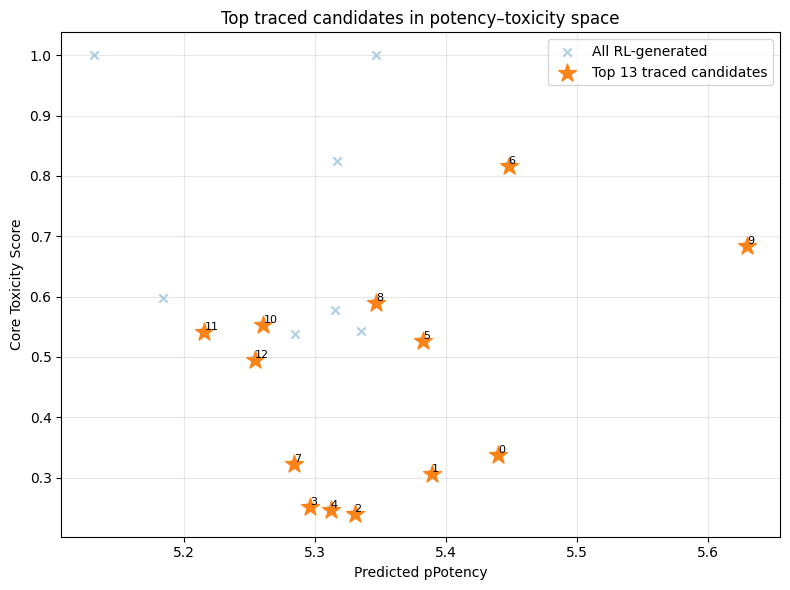

In [8]:
def plotPotencyToxicity(generatedDF, topCandidateDF, outPath):
    plt.figure(figsize=(8, 6))

    if {"pPotency_prediction", "coreToxicityScore"}.issubset(generatedDF.columns):
        plt.scatter(
            generatedDF["pPotency_prediction"],
            generatedDF["coreToxicityScore"],
            marker="x",
            alpha=0.35,
            label="All RL-generated",
        )

    if {"pPotency_prediction", "coreToxicityScore"}.issubset(topCandidateDF.columns):
        plt.scatter(
            topCandidateDF["pPotency_prediction"],
            topCandidateDF["coreToxicityScore"],
            marker="*",
            s=180,
            alpha=0.95,
            label=f"Top {len(topCandidateDF)} traced candidates",
        )

        for idx, row in topCandidateDF.iterrows():
            plt.text(
                row["pPotency_prediction"],
                row["coreToxicityScore"],
                str(idx),
                fontsize=8,
                ha="left",
                va="bottom",
            )

    plt.xlabel("Predicted pPotency")
    plt.ylabel("Core Toxicity Score")
    plt.title("Top traced candidates in potency–toxicity space")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(outPath, dpi=300)
    plt.show()

plotPotencyToxicity(
    generatedDF=generatedDF,
    topCandidateDF=topCandidateDF,
    outPath=traceOutputDir / "top_traced_candidates_potency_toxicity.png",
)


## 9. Molecule grid for top candidates

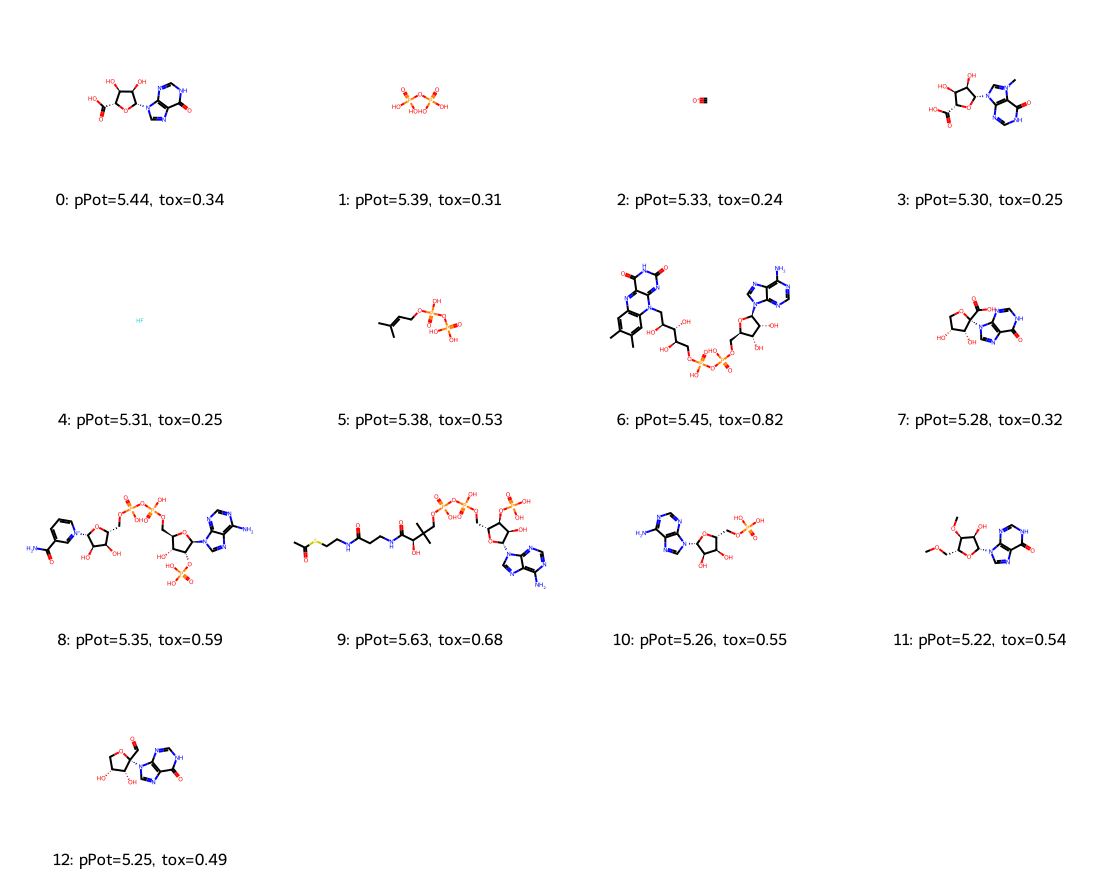

Could not save molecule grid: 'Image' object has no attribute 'save'


In [9]:
legends = []
smilesList = []
for idx, row in topCandidateDF.iterrows():
    smilesList.append(row["SMILES"])
    pot = row.get("pPotency_prediction", np.nan)
    tox = row.get("coreToxicityScore", np.nan)
    legends.append(f"{idx}: pPot={pot:.2f}, tox={tox:.2f}")

img = displayMoleculeGrid(smilesList, legends=legends, molsPerRow=4)
display(img)

# Save PNG version
try:
    img.save(str(traceOutputDir / "top_candidate_molecule_grid.png"))
except Exception as exc:
    print("Could not save molecule grid:", exc)


## 10. Visualize route steps for a selected candidate

Change `candidateIndex` to inspect another candidate.

,candidateIndex,candidateSmiles,stepIndex,sourceSmiles,productSmiles,jobName,jsonFile,actionIndex,pPotency_prediction,coreToxicityScore,QED,pPotency_std
0,0,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@H]2OP(=O...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rl_tmp_c0bfe20b2257,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,23,5.629883,0.683606,0.058692,0.545017


Candidate SMILES: CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cnc3c(N)ncnc32)[C@H](O)[C@@H]1OP(=O)(O)O


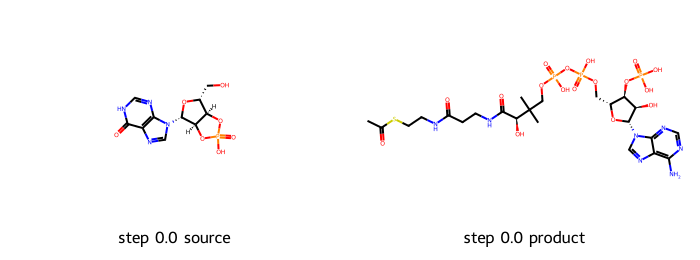

Could not save route image: 'Image' object has no attribute 'save'


In [10]:
candidateIndex = 0

candidateRows = routeStepDF[routeStepDF["candidateIndex"] == candidateIndex].copy()
display(candidateRows)

candidateSmiles = matchedRouteDF.loc[candidateIndex, "SMILES"] if candidateIndex < len(matchedRouteDF) else None
print("Candidate SMILES:", candidateSmiles)

routeSmiles = []
routeLegends = []

for _, step in candidateRows.iterrows():
    src = step.get("sourceSmiles")
    prod = step.get("productSmiles")
    stepIdx = step.get("stepIndex")

    if isinstance(src, str) and src not in routeSmiles:
        routeSmiles.append(src)
        routeLegends.append(f"step {stepIdx} source")

    if isinstance(prod, str) and prod not in routeSmiles:
        routeSmiles.append(prod)
        routeLegends.append(f"step {stepIdx} product")

if routeSmiles:
    routeImg = displayMoleculeGrid(routeSmiles, legends=routeLegends, molsPerRow=2, subImgSize=(350, 260))
    display(routeImg)
    try:
        routeImg.save(str(traceOutputDir / f"candidate_{candidateIndex}_route_molecules.png"))
    except Exception as exc:
        print("Could not save route image:", exc)
else:
    print("No route SMILES available for this candidate.")


## 11. Optional: draw a source → product route graph

This uses NetworkX if available. It visualizes only the selected candidate route metadata, not the full DORAnet reaction network.

/tmp/ipykernel_174866/3039172408.py:24: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle="->", arrowsize=18)


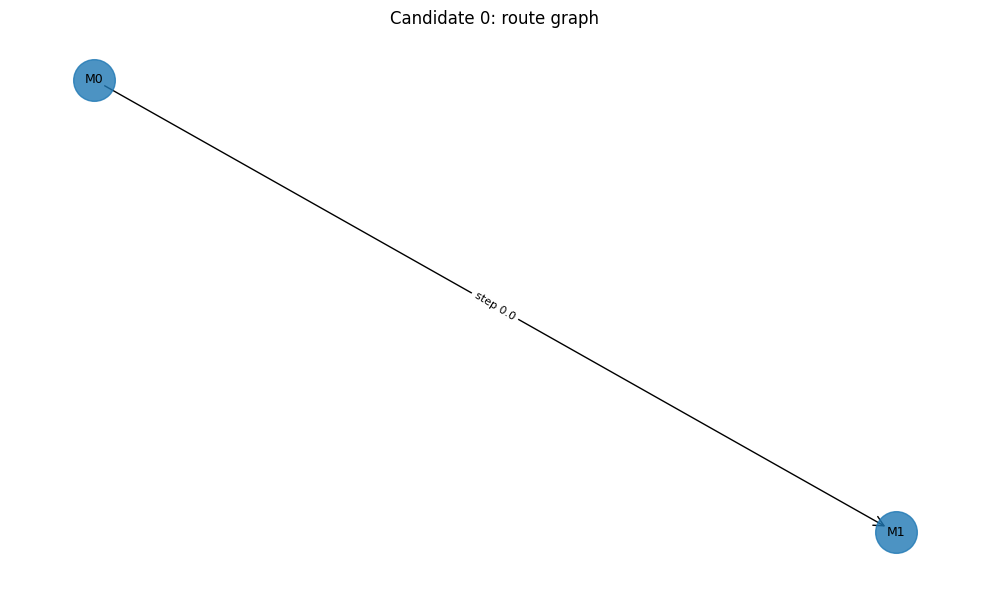

,nodeLabel,SMILES
0,M0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@H]2OP(=O...
1,M1,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...


In [11]:
try:
    import networkx as nx

    def plotCandidateRouteGraph(candidateRows, candidateIndex, outPath=None):
        G = nx.DiGraph()

        for _, step in candidateRows.iterrows():
            src = step.get("sourceSmiles")
            prod = step.get("productSmiles")
            label = f"step {step.get('stepIndex')}"

            if isinstance(src, str) and isinstance(prod, str):
                G.add_node(src)
                G.add_node(prod)
                G.add_edge(src, prod, label=label)

        if len(G.nodes) == 0:
            print("No graph edges available.")
            return

        plt.figure(figsize=(10, 6))
        pos = nx.spring_layout(G, seed=7, k=1.5)
        nx.draw_networkx_nodes(G, pos, node_size=900, alpha=0.8)
        nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle="->", arrowsize=18)
        labels = {node: f"M{i}" for i, node in enumerate(G.nodes)}
        nx.draw_networkx_labels(G, pos, labels=labels, font_size=9)
        edgeLabels = nx.get_edge_attributes(G, "label")
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edgeLabels, font_size=8)
        plt.title(f"Candidate {candidateIndex}: route graph")
        plt.axis("off")
        plt.tight_layout()

        if outPath is not None:
            plt.savefig(outPath, dpi=300)
        plt.show()

        mappingDF = pd.DataFrame({"nodeLabel": [labels[n] for n in G.nodes], "SMILES": list(G.nodes)})
        return mappingDF

    nodeMapDF = plotCandidateRouteGraph(
        candidateRows,
        candidateIndex=candidateIndex,
        outPath=traceOutputDir / f"candidate_{candidateIndex}_route_graph.png",
    )
    if nodeMapDF is not None:
        display(nodeMapDF)
        nodeMapDF.to_csv(traceOutputDir / f"candidate_{candidateIndex}_route_graph_node_map.csv", index=False)

except ImportError:
    print("NetworkX is not installed in this environment. Skipping route graph.")


## 12. Create per-candidate trace JSON files

Each trace file contains:
- candidate score metadata
- route source/product/job/json metadata
- compact summaries of DORAnet JSON networks used by that route


In [12]:
def buildCandidateTrace(row, routeStepDF):
    candIdx = int(row.name)
    candRouteDF = routeStepDF[routeStepDF["candidateIndex"] == candIdx].copy()

    candidateInfo = {}
    for col in row.index:
        val = row[col]
        if isinstance(val, (np.integer, np.floating)):
            val = val.item()
        candidateInfo[col] = None if pd.isna(val) else val

    routeSteps = candRouteDF.to_dict(orient="records")
    for step in routeSteps:
        for key, val in list(step.items()):
            if isinstance(val, (np.integer, np.floating)):
                step[key] = val.item()
            elif pd.isna(val):
                step[key] = None

    networkSummaries = []
    for jf in candRouteDF["jsonFile"].dropna().drop_duplicates():
        networkSummaries.append(summarizeReactionJson(jf))

    return {
        "candidate": candidateInfo,
        "routeSteps": routeSteps,
        "reactionNetworkSummaries": networkSummaries,
    }


traceFiles = []
for idx, row in matchedRouteDF.iterrows():
    trace = buildCandidateTrace(row, routeStepDF)
    outFile = traceOutputDir / f"candidate_{idx:03d}_trace.json"
    with open(outFile, "w") as f:
        json.dump(trace, f, indent=2)
    traceFiles.append(str(outFile))

summaryDF = matchedRouteDF.copy()
summaryDF["traceFile"] = traceFiles
summaryCols = [c for c in [
    "SMILES", "pPotency_prediction", "coreToxicityScore", "QED", "pPotency_std",
    "reward", "routeLength", "preferencePolicy", "traceFile"
] if c in summaryDF.columns]
summaryDF[summaryCols].to_csv(traceOutputDir / "trace_summary.csv", index=False)

display(summaryDF[summaryCols].head(topK))
print("Saved trace files to:", traceOutputDir)


,SMILES,pPotency_prediction,coreToxicityScore,QED,pPotency_std,reward,routeLength,preferencePolicy,traceFile
0,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,5.629883,0.683606,0.058692,0.545017,0.299914,1,potency_focused,RL_outputs_multiobjective/reaction_trace_postp...
1,C[n+]1cn([C@@H]2O[C@H](C(=O)O)[C@@H](O)[C@H]2O...,5.296519,0.251765,0.440238,0.541002,0.191499,0,safety_focused,RL_outputs_multiobjective/reaction_trace_postp...
2,C#[O+],5.330150,0.239987,0.333625,0.544133,0.175978,1,balanced,RL_outputs_multiobjective/reaction_trace_postp...
3,F,5.311845,0.246626,0.350795,0.544203,0.165281,0,balanced,RL_outputs_multiobjective/reaction_trace_postp...
4,O=P(O)(O)OP(=O)(O)O,5.389426,0.306393,0.407078,0.542553,0.151562,1,balanced,RL_outputs_multiobjective/reaction_trace_postp...
5,O=C(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H]...,5.439854,0.337565,0.485234,0.540909,0.143443,0,safety_focused,RL_outputs_multiobjective/reaction_trace_postp...
6,O=C(O)[C@]1(n2cnc3c(=O)[nH]cnc32)OC[C@@H](O)[C...,5.284240,0.322860,0.475998,0.543808,0.111039,0,safety_focused,RL_outputs_multiobjective/reaction_trace_postp...
7,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,5.447737,0.816600,0.044261,0.540431,0.013414,3,potency_focused,RL_outputs_multiobjective/reaction_trace_postp...
8,O=C[C@]1(n2cnc3c(=O)[nH]cnc32)OC[C@@H](O)[C@H]1O,5.254010,0.494737,0.521934,0.544925,-0.008645,0,potency_focused,RL_outputs_multiobjective/reaction_trace_postp...
9,CC(C)=CCOP(=O)(O)OP(=O)(O)O,5.382517,0.526286,0.492503,0.543583,-0.111489,3,safety_focused,RL_outputs_multiobjective/reaction_trace_postp...


Saved trace files to: RL_outputs_multiobjective/reaction_trace_postprocessing


## 13. Optional: copy DORAnet JSON files used by top candidates

This makes a self-contained folder containing only the networks relevant to top candidates.

In [13]:
import shutil

copyJsonFiles = True
jsonCopyDir = traceOutputDir / "doranet_json_files_for_top_candidates"
jsonCopyDir.mkdir(exist_ok=True)

if copyJsonFiles:
    copied = []
    for jf in routeStepDF["jsonFile"].dropna().drop_duplicates():
        src = Path(str(jf))
        if src.exists():
            dst = jsonCopyDir / src.name
            if not dst.exists():
                shutil.copy2(src, dst)
            copied.append(str(dst))
    print(f"Copied {len(copied)} JSON files to: {jsonCopyDir}")
else:
    print("JSON copy disabled.")


Copied 0 JSON files to: RL_outputs_multiobjective/reaction_trace_postprocessing/doranet_json_files_for_top_candidates


## 14. Final output files

The notebook writes the following files into `reaction_trace_postprocessing/`:

- `top_candidates_selected.csv`
- `top_candidates_with_route_metadata.csv`
- `top_candidate_route_steps.csv`
- `doranet_json_summary_for_top_candidates.csv`
- `top_traced_candidates_potency_toxicity.png`
- `top_candidate_molecule_grid.png`
- `candidate_XXX_trace.json`
- `trace_summary.csv`
- optional copied DORAnet JSON files
